<a href="https://colab.research.google.com/github/Madathanapalleleena/DL_exploration/blob/main/autocoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.3072 - val_loss: 0.2655
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2645 - val_loss: 0.2633
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2581 - val_loss: 0.2505
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.2421 - val_loss: 0.2311
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.2215 - val_loss: 0.2116
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2056 - val_loss: 0.1983
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1939 - val_loss: 0.1877
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1841 - val_loss: 0.1787
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1758 - val_loss: 0.1711
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1688 - val_loss: 0.1647
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


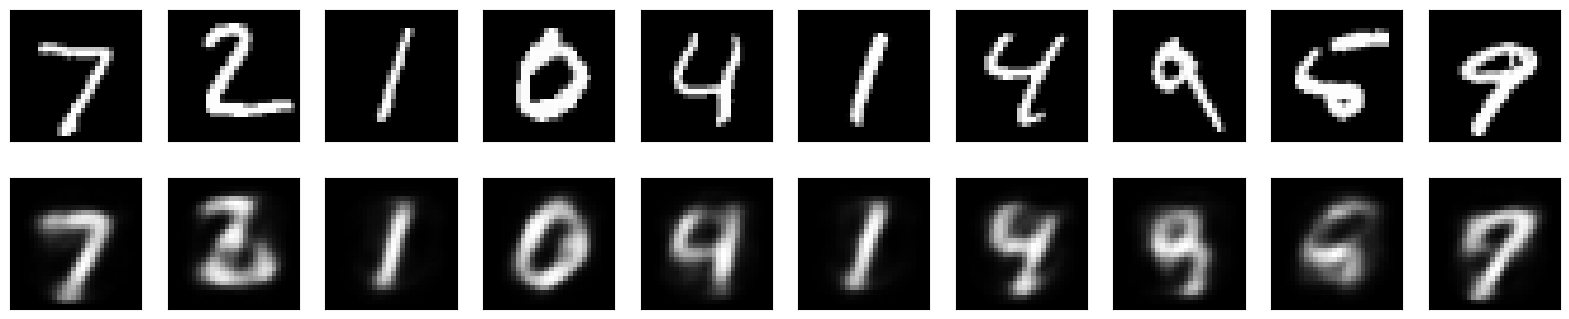

Mean Squared Error (MSE) on test set: 0.03252
Approximate pixel-level accuracy: 73.90%


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 62  # 62 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=10, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()
# 7. Evaluate (pixel-level similarity)
mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE) on test set: {mse:.5f}")

# Optional: Simple "accuracy" metric
# Count pixels that match closely (difference < 0.1)
accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approximate pixel-level accuracy: {accuracy*100:.2f}%")

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.2438 - val_loss: 0.1612
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1434 - val_loss: 0.1275
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1188 - val_loss: 0.1090
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1042 - val_loss: 0.0978
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0946 - val_loss: 0.0900
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0882 - val_loss: 0.0846
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0838 - val_loss: 0.0813
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0808 - val_loss: 0.0789
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0788 - val_loss: 0.0773
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0775 - val_loss: 0.0762
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0765 - val_loss: 0.0754
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

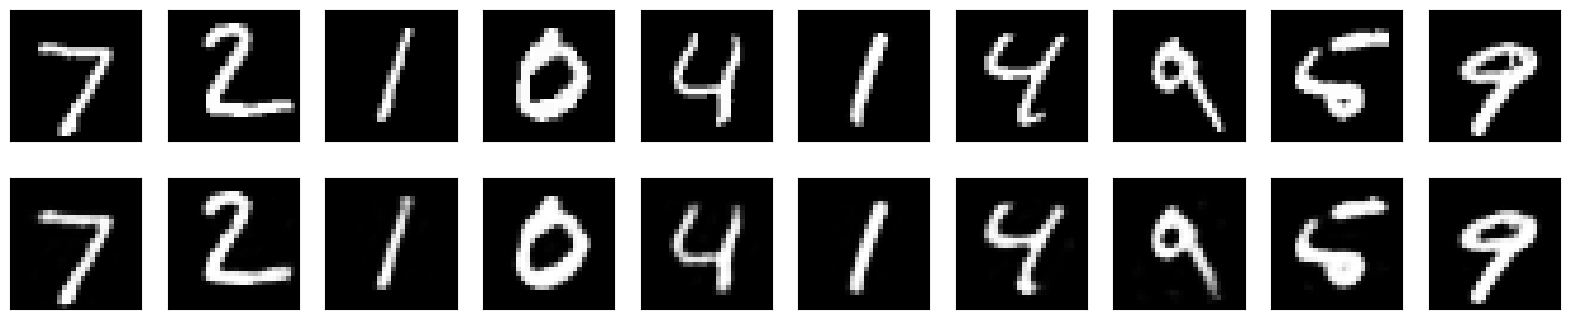

Mean Squared Error (MSE) on test set: 0.00389
Approximate pixel-level accuracy: 93.98%


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 64  # 64 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=20, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()
# 7. Evaluate (pixel-level similarity)
mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE) on test set: {mse:.5f}")

# Optional: Simple "accuracy" metric
# Count pixels that match closely (difference < 0.1)
accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approximate pixel-level accuracy: {accuracy*100:.2f}%")

**Hidden layers → ReLU**

**Output layer → Sigmoid**


ReLU works better than Sigmoid in hidden layers because it avoids vanishing gradients, allows faster learning, and captures more detailed features, while Sigmoid compresses values and slows training.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


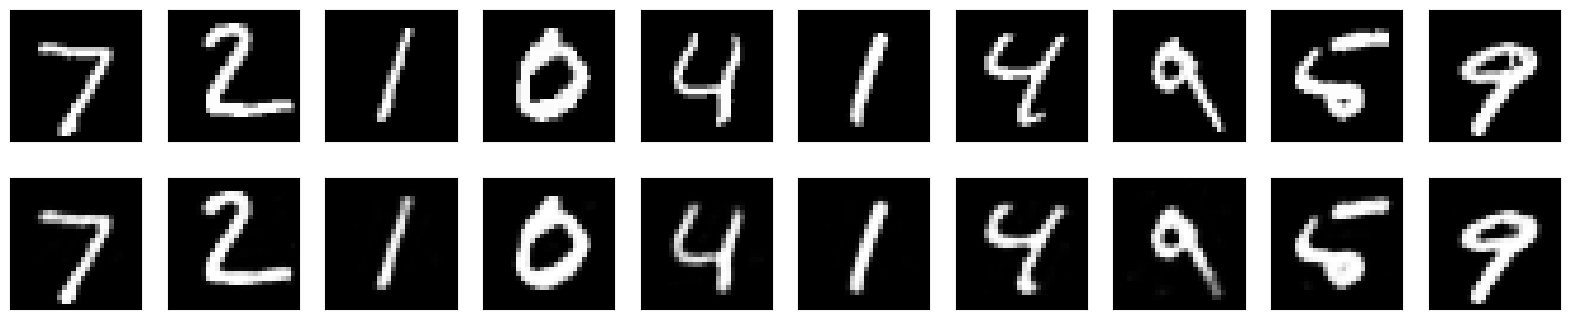

Mean Squared Error (MSE) on test set: 0.00363
Approximate pixel-level accuracy: 94.22%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


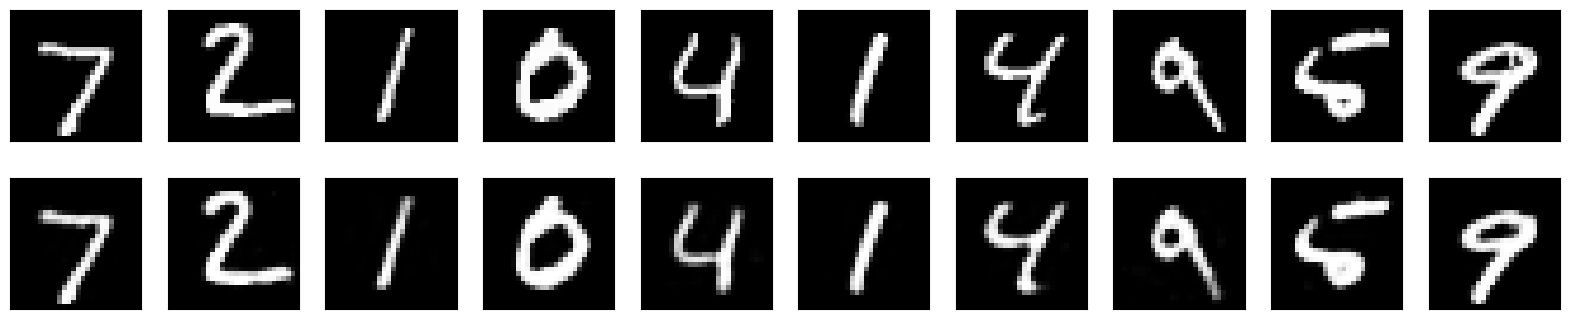

Mean Squared Error (MSE) on test set: 0.00364
Approximate pixel-level accuracy: 94.24%


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 64  # 64 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, verbose=0,validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()
# 7. Evaluate (pixel-level similarity)
mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE) on test set: {mse:.5f}")

# Optional: Simple "accuracy" metric
# Count pixels that match closely (difference < 0.1)
accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approximate pixel-level accuracy: {accuracy*100:.2f}%")

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.2036 - mse: 0.0471 - val_loss: 0.1381 - val_mse: 0.0251
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.1289 - mse: 0.0220 - val_loss: 0.1205 - val_mse: 0.0194
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.1174 - mse: 0.0182 - val_loss: 0.1111 - val_mse: 0.0162
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.1089 - mse: 0.0154 - val_loss: 0.1043 - val_mse: 0.0140
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.1044 - mse: 0.0139 - val_loss: 0.1021 - val_mse: 0.0133
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1015 - mse: 0.0130 - val_loss: 0.0993 - val_mse: 0.0124
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0993 - mse: 0.0123 - val_loss: 0.0974 - val_mse: 0.0117
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0977 - mse: 0.0118 - val_loss: 0.0962 - val_mse: 0.0113
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms

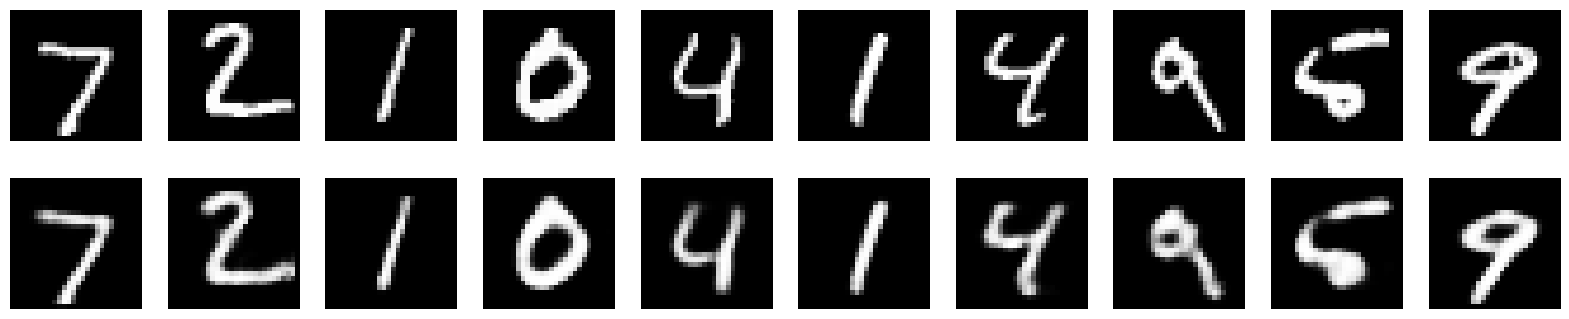

Mean Squared Error (MSE) on test set: 0.00755
Approximate pixel-level accuracy: 91.05%


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# 2. Define a Better Autoencoder (More neurons for better reconstruction)
input_layer = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)  # bottleneck

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)

# 3. Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mse'])

# 4. Train
history = autoencoder.fit(
    x_train, x_train,
    epochs=30,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# 5. Predict
decoded_imgs = autoencoder.predict(x_test)

# 6. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

# 7. Evaluate (pixel-level similarity)
mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE) on test set: {mse:.5f}")

# Optional: Simple "accuracy" metric
# Count pixels that match closely (difference < 0.1)
accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approximate pixel-level accuracy: {accuracy*100:.2f}%")

# **Conclusions:**


**when the data is --> epochs=20, batch_size=256, shuffle=True**

input_dim = 784  # 28x28 images

encoding_dim = 64  # 64 features - Compressed representation

relu --> in hidden layer

sigmoid --> output layer

**Output:**

Mean Squared Error (MSE) on test set: 0.00389

Approximate pixel-level accuracy: 93.98%


---



**when the data is --> epochs=20, batch_size=256, shuffle=True**

input_dim = 784  # 28x28 images

encoding_dim = 64  # 64 features - Compressed representation

sigmoid --> in hidden layer

sigmoid --> output layer

Mean Squared Error (MSE) on test set: 0.03252

Approximate pixel-level accuracy: 73.90%



---

**when the data is --> epochs=50, batch_size=256, shuffle=True**

input_dim = 784  # 28x28 images

encoding_dim = 64  # 64 features - Compressed representation

relu --> in hidden layer

sigmoid --> output layer

Mean Squared Error (MSE) on test set: 0.00363

Approximate pixel-level accuracy: 94.22%


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

# Load data
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten (28x28 → 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

print(x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)


**Undercomplete Autoencoder**

Latent dimension smaller than input (784)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.2786 - val_loss: 0.1891
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1707 - val_loss: 0.1537
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1440 - val_loss: 0.1328
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1277 - val_loss: 0.1203
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1175 - val_loss: 0.1122
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1106 - val_loss: 0.1064
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1055 - val_loss: 0.1021
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1017 - val_loss: 0.0989
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0990 - val_loss: 0.0967
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0972 - val_loss: 0.0953
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


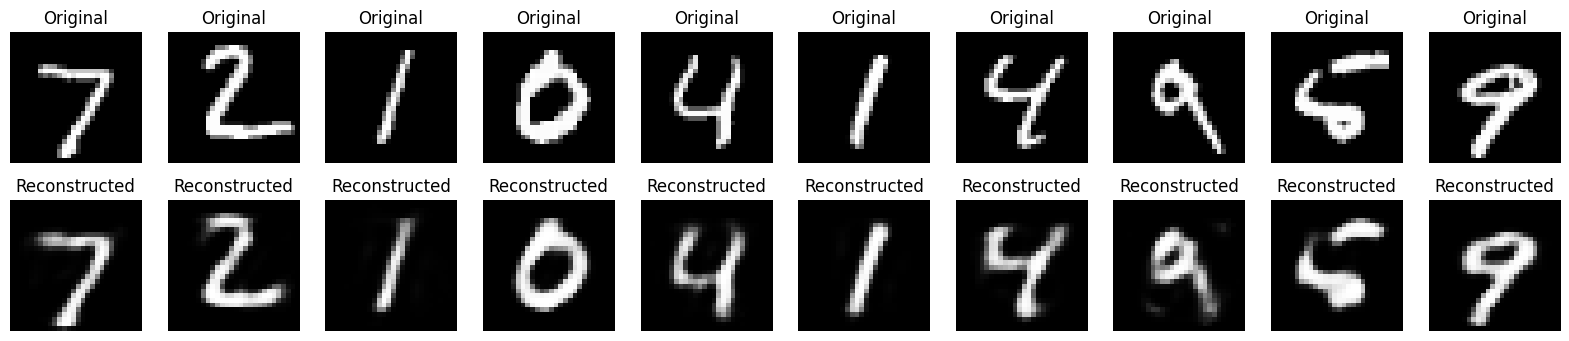

In [4]:
encoding_dim = 32  # LOW DIMENSION

input_img = Input(shape=(784,))
encoded = Dense(encoding_dim, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# Encode & Decode
encoder = Model(input_img, encoded)
encoded_imgs = encoder.predict(x_test)
decoded_imgs = autoencoder.predict(x_test)
import matplotlib.pyplot as plt

n = 10  # number of images to display
plt.figure(figsize=(20, 4))

for i in range(n):
    # 🔹 Original Image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # 🔹 Reconstructed Image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

Model learns important features only

Reconstruction:

* Slight blur

* Still recognizable digits

**Conclusion:**
Good compression achieved up to ~32–64 dimensions without losing major information.

**Overcomplete Encoder**

Latent dimension greater than input

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - loss: 0.1372 - val_loss: 0.0810
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - loss: 0.0749 - val_loss: 0.0701
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - loss: 0.0689 - val_loss: 0.0673
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - loss: 0.0669 - val_loss: 0.0663
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - loss: 0.0659 - val_loss: 0.0653
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - loss: 0.0653 - val_loss: 0.0648
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - loss: 0.0649 - val_loss: 0.0645
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - loss: 0.0646 - val_loss: 0.0643
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - loss: 0.0644 - val_loss: 0.0642
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - loss: 0.0642 - val_loss: 0.0639
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


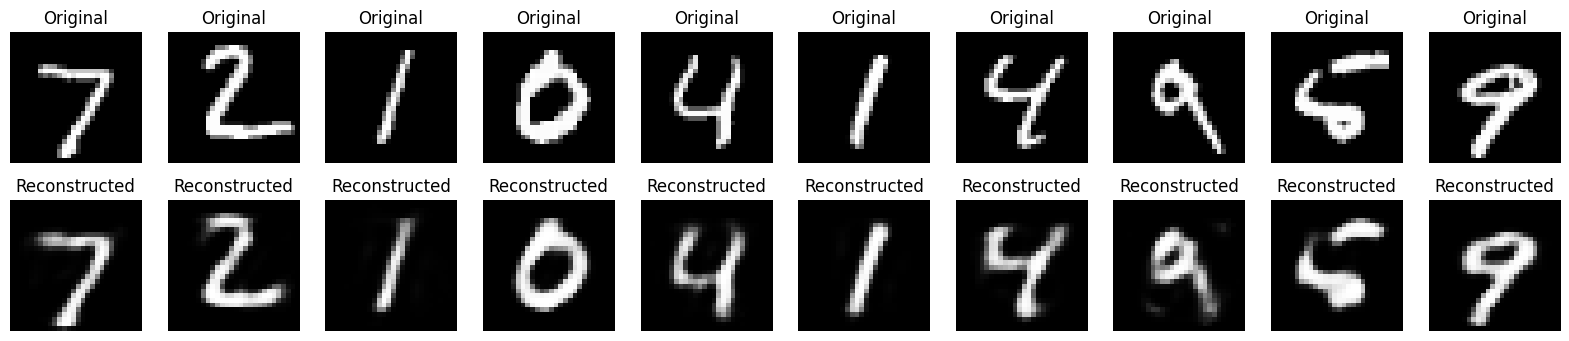

In [5]:
encoding_dim = 1024  # HIGH DIMENSION

input_img = Input(shape=(784,))
encoded = Dense(encoding_dim, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder_over = Model(input_img, decoded)
autoencoder_over.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder_over.fit(x_train, x_train,
                     epochs=10,
                     batch_size=256,
                     shuffle=True,
                     validation_data=(x_test, x_test))

decoded_imgs_over = autoencoder_over.predict(x_test)
import matplotlib.pyplot as plt

n = 10  # number of images to display
plt.figure(figsize=(20, 4))

for i in range(n):
    # 🔹 Original Image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # 🔹 Reconstructed Image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

Model tends to memorize input

Without regularization:

No meaningful feature learning

**Conclusion:**
Overcomplete AE needs regularization, otherwise it behaves like identity mapping.

**Autoencoder with Regularization**

Prevents overfitting (important for overcomplete AE)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.4009 - val_loss: 0.2685
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.2398 - val_loss: 0.2215
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.2141 - val_loss: 0.2057
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.2012 - val_loss: 0.1951
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.1921 - val_loss: 0.1872
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1851 - val_loss: 0.1811
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1798 - val_loss: 0.1765
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1758 - val_loss: 0.1729
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1725 - val_loss: 0.1699
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.1698 - val_loss: 0.1672
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


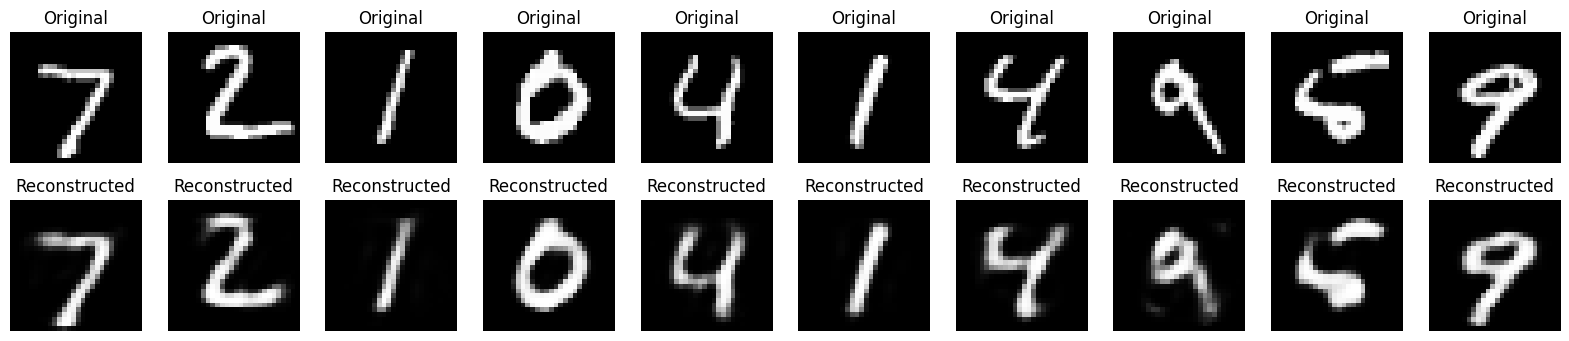

In [9]:
encoding_dim = 128

input_img = Input(shape=(784,))
encoded = Dense(encoding_dim, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder_reg = Model(input_img, decoded)
autoencoder_reg.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder_reg.fit(x_train, x_train,
                    epochs=10,
                    batch_size=256,
                    shuffle=True,
                    validation_data=(x_test, x_test))

decoded_imgs_reg = autoencoder_reg.predict(x_test)
n = 10
plt.figure(figsize=(20,4))

for i in range(n):
    # original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # reconstructed
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

L1 regularization forces sparse encoding

Benefits:

* Better generalization
* Removes unnecessary activations

**Conclusion:**
Regularization helps even high-dimensional AE behave like compressed models.

**Denoising Autoencoder**

Add noise and reconstruct

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 0.2362 - val_loss: 0.1682
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.1534 - val_loss: 0.1404
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.1351 - val_loss: 0.1283
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.1260 - val_loss: 0.1221
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.1211 - val_loss: 0.1186
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.1179 - val_loss: 0.1160
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1155 - val_loss: 0.1141
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1138 - val_loss: 0.1129
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.1126 - val_loss: 0.1121
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1116 - val_loss: 0.1113
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


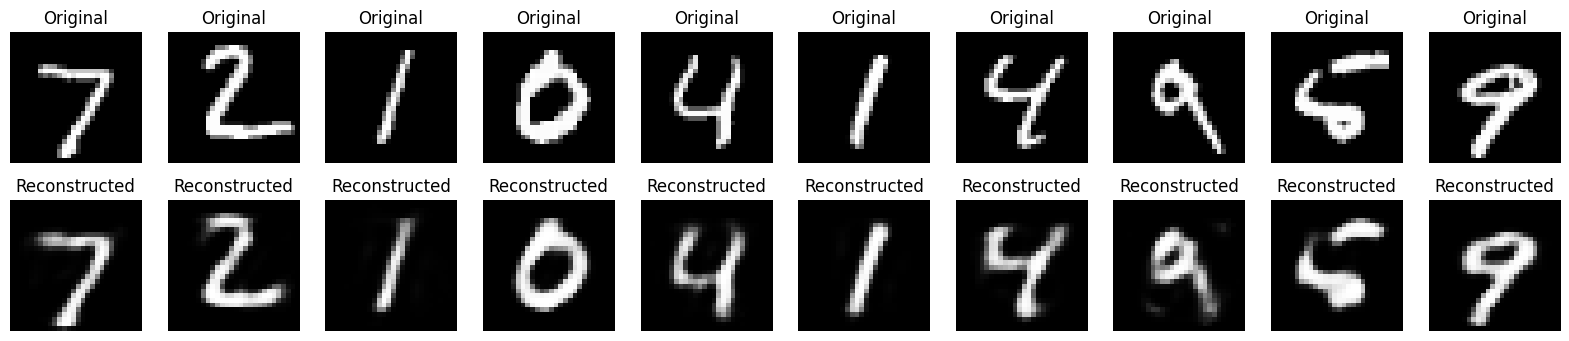

In [7]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Model
input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

denoise_ae = Model(input_img, decoded)
denoise_ae.compile(optimizer='adam', loss='binary_crossentropy')

denoise_ae.fit(x_train_noisy, x_train,
               epochs=10,
               batch_size=256,
               shuffle=True,
               validation_data=(x_test_noisy, x_test))

decoded_imgs_denoise = denoise_ae.predict(x_test_noisy)
n = 10
plt.figure(figsize=(20,6))

for i in range(n):
    # noisy
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')
    # clean
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    # reconstructed
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(decoded_imgs_denoise[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')
plt.show()

Noise factor = 0.5 works well

Observations:

* Up to 40–50% noise → still reconstructable

* Above 0.7 → quality degrades significantly

**Conclusion:**
Model learns robust features, not just pixel mapping.

**PCA vs Autoencoder**

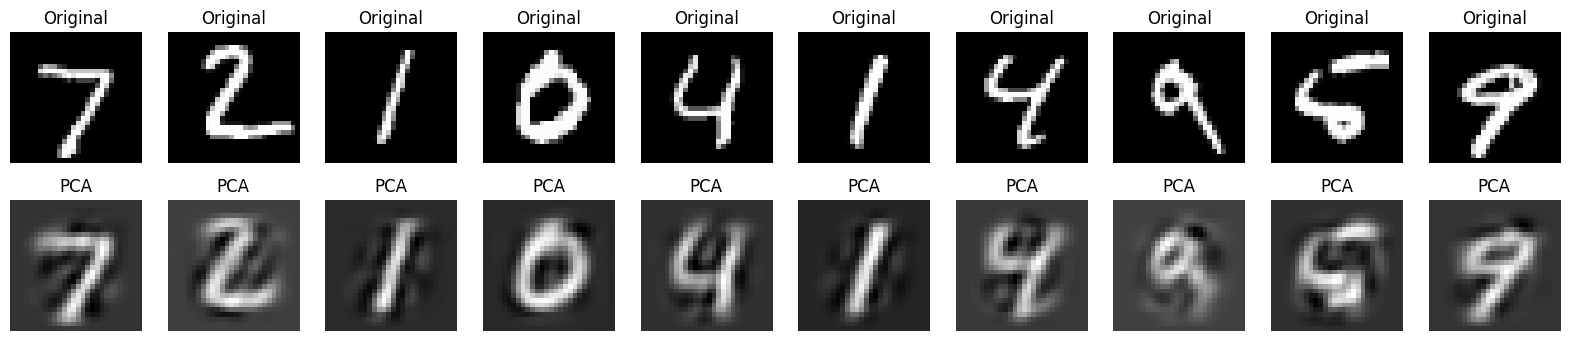

In [8]:
from sklearn.decomposition import PCA

# PCA with same dimension as AE (32)
pca = PCA(n_components=32)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

x_test_reconstructed = pca.inverse_transform(x_test_pca)

# Compare visualization
n = 10
plt.figure(figsize=(20,4))

for i in range(n):
    # original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # PCA
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(x_test_reconstructed[i].reshape(28,28), cmap='gray')
    plt.title("PCA")
    plt.axis('off')

plt.show()

PCA:

* Linear transformation
* Blurry outputs

AE:

* Non-linear learning
* Better reconstruction

**Conclusion:**
Autoencoders outperform PCA for complex patterns like images.